CSCI218 GroupProject Machine Learning (Rice Data Sets) (Logical Regression)

**Environment Setup and Data Extraction**

In [20]:
# Libraries for data handling
import pandas as pd
from scipy.io import arff
import zipfile
import os

# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Unzip the dataset
zip_path = '/content/rice+cammeo+and+osmancik.zip'
extract_path = '/content/rice_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted successfully:", os.listdir(extract_path))

Files extracted successfully: ['Rice_Cammeo_Osmancik.arff', 'Citation_Request.txt']


**Data Acquisition & Feature Engineering Pipeline**

In [28]:
# Load the .arff file
data, meta = arff.loadarff('/content/rice_data/Rice_Cammeo_Osmancik.arff')
df = pd.DataFrame(data)

# 1. Convert byte strings to standard strings
df['Class'] = df['Class'].str.decode('utf-8')

# 2. ADD THE NEW FEATURE HERE (Feature Engineering)
# Convex_Area / Area is a measure of "Solidity"
df['Convex_Area_Ratio'] = df['Convex_Area'] / df['Area']

# Display the structure and the first 5 records
print("--- Dataframe Info ---")
print(df.info())

print("\n--- First 5 Records of the Dataset ---")
print(df.head(5))

--- Dataframe Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3810 non-null   float64
 1   Perimeter          3810 non-null   float64
 2   Major_Axis_Length  3810 non-null   float64
 3   Minor_Axis_Length  3810 non-null   float64
 4   Eccentricity       3810 non-null   float64
 5   Convex_Area        3810 non-null   float64
 6   Extent             3810 non-null   float64
 7   Class              3810 non-null   object 
 8   Convex_Area_Ratio  3810 non-null   float64
dtypes: float64(8), object(1)
memory usage: 268.0+ KB
None

--- First 5 Records of the Dataset ---
      Area   Perimeter  Major_Axis_Length  Minor_Axis_Length  Eccentricity  \
0  15231.0  525.578979         229.749878          85.093788      0.928882   
1  14656.0  494.311005         206.020065          91.730972      0.895405   
2  14634.0

**Exploratory Data Analysis**

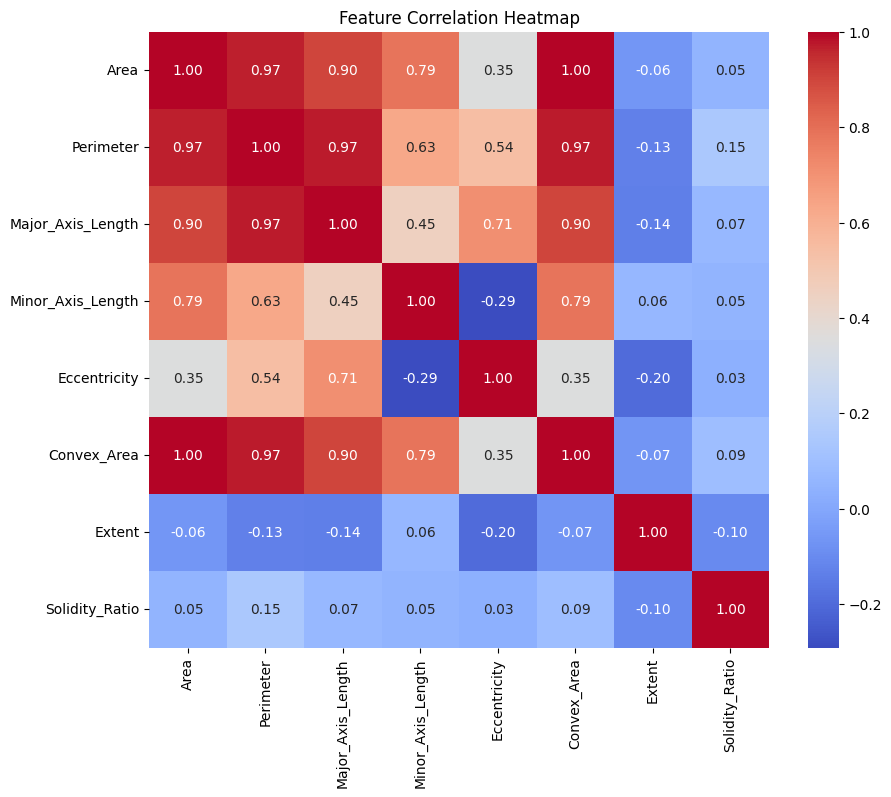

/tmp/ipython-input-3885049387.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=col, data=df, palette="Set2")
/tmp/ipython-input-3885049387.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=col, data=df, palette="Set2")
/tmp/ipython-input-3885049387.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y=col, data=df, palette="Set2")
/tmp/ipython-input-3885049387.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to 

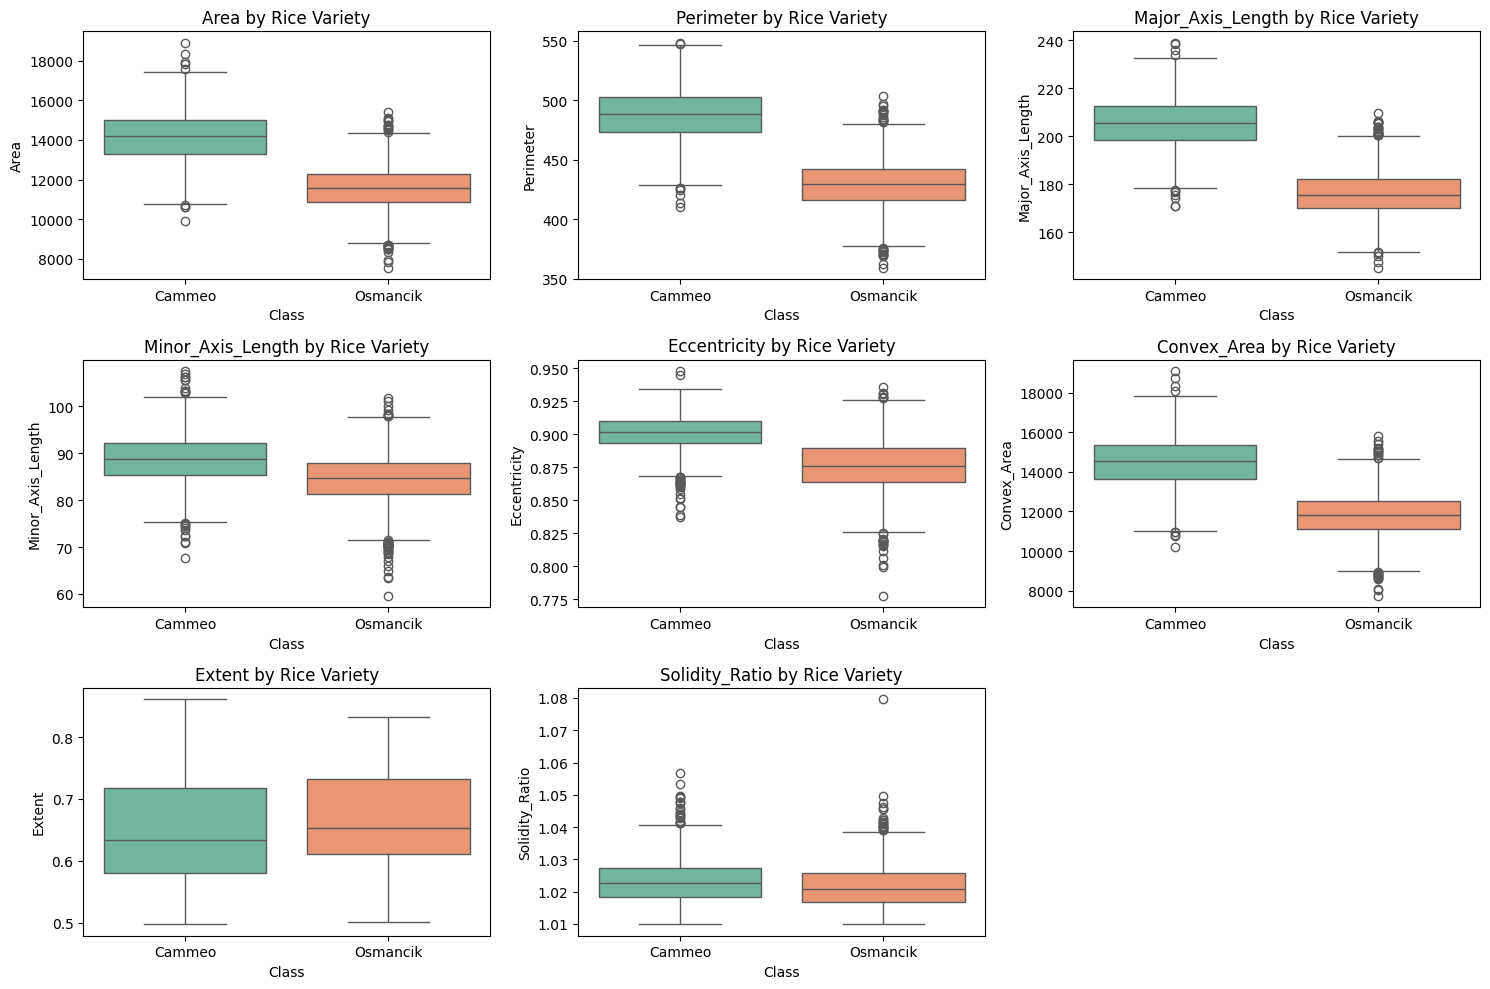

In [22]:
# 1. Correlation Heatmap to see feature relationships
plt.figure(figsize=(10, 8))
sns.heatmap(df.drop('Class', axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

# 2. Boxplots to compare feature distributions by class
plt.figure(figsize=(15, 10))
features = df.drop('Class', axis=1).columns
for i, col in enumerate(features):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x='Class', y=col, data=df, palette="Set2")
    plt.title(f'{col} by Rice Variety')
plt.tight_layout()
plt.show()

**Data Preprocessing**

In [23]:
# Split Features (X) and Target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# First Split: Separate 20% for the final Test Set
# Remaining 80% will be split again into Train and Validation
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Second Split: Split the 80% (temp) into 60% Train and 20% Validation
# To get 20% of the total from the 80% remaining, we use test_size=0.25 (since 0.25 * 0.8 = 0.2)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# Feature Scaling
scaler = StandardScaler()

# Fit on Train only to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Data successfully split:")
print(f"Training set size: {len(X_train)} (60%)")
print(f"Validation set size: {len(X_val)} (20%)")
print(f"Test set size: {len(X_test)} (20%)")

Data successfully split:
Training set size: 2286 (60%)
Validation set size: 762 (20%)
Test set size: 762 (20%)


**Model Training and Cross-Validation**

In [24]:
# Initialize Logistic Regression
log_reg = LogisticRegression(max_iter=1000)

# Perform 5-Fold Cross-Validation on training data
cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5)

# Fit the model on the full training set
log_reg.fit(X_train_scaled, y_train)

print(f"Cross-Validation Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation of CV Scores: {cv_scores.std():.4f}")

Cross-Validation Mean Accuracy: 0.9326
Standard Deviation of CV Scores: 0.0132


Hyperparameter Tuning (using Validation Set)

In [25]:
# List of C values to test (Regularization strength)
c_values = [0.001, 0.01, 0.1, 1, 10, 100]
best_score = 0
best_c = None

print("--- Starting Hyperparameter Tuning ---")

for c in c_values:
    # Initialize and train with a specific C
    model = LogisticRegression(C=c, max_iter=1000)
    model.fit(X_train_scaled, y_train)

    # Check performance on the Validation Set
    score = model.score(X_val_scaled, y_val)
    print(f"Testing C={c}: Validation Accuracy = {score:.4f}")

    # Save the best version
    if score > best_score:
        best_score = score
        best_c = c

print(f"\nOptimization Complete!")
print(f"Best C value found: {best_c} with Validation Accuracy of {best_score:.4f}")

--- Starting Hyperparameter Tuning ---
Testing C=0.001: Validation Accuracy = 0.9160
Testing C=0.01: Validation Accuracy = 0.9226
Testing C=0.1: Validation Accuracy = 0.9278
Testing C=1: Validation Accuracy = 0.9278
Testing C=10: Validation Accuracy = 0.9304
Testing C=100: Validation Accuracy = 0.9291

Optimization Complete!
Best C value found: 10 with Validation Accuracy of 0.9304


**Advanced Model Evaluation**

--- FINAL TEST SET RESULTS ---
              precision    recall  f1-score   support

      Cammeo       0.93      0.91      0.92       350
    Osmancik       0.92      0.94      0.93       412

    accuracy                           0.93       762
   macro avg       0.93      0.93      0.93       762
weighted avg       0.93      0.93      0.93       762



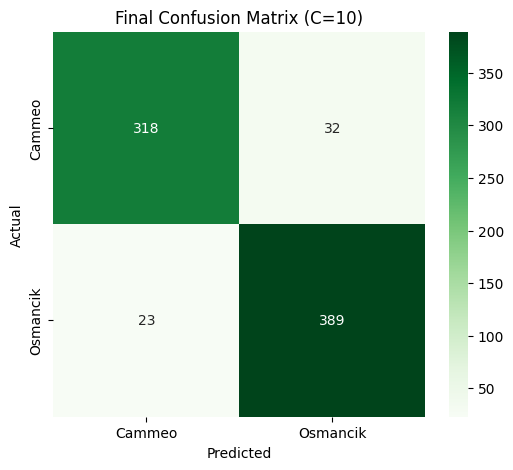

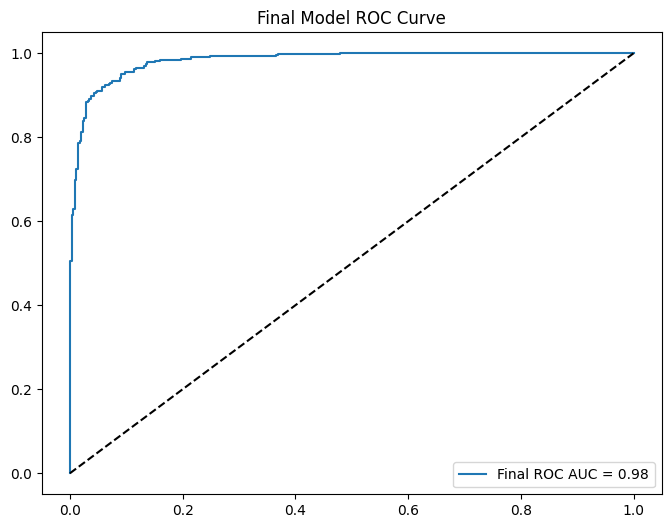

In [26]:
# 1. Initialize final model with the best_c found above
final_log_reg = LogisticRegression(C=best_c, max_iter=1000)
final_log_reg.fit(X_train_scaled, y_train)

# 2. Final Predictions on the hidden Test Set
y_pred = final_log_reg.predict(X_test_scaled)
y_prob = final_log_reg.predict_proba(X_test_scaled)[:, 1]

# 3. Print Final Results
print("--- FINAL TEST SET RESULTS ---")
print(classification_report(y_test, y_pred))

# 4. Final Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=final_log_reg.classes_, yticklabels=final_log_reg.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Final Confusion Matrix (C={best_c})')
plt.show()

# 5. ROC Curve for Final Model
y_test_binary = y_test.map({'Cammeo': 0, 'Osmancik': 1})
fpr, tpr, _ = roc_curve(y_test_binary, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Final ROC AUC = {auc(fpr, tpr):.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Final Model ROC Curve')
plt.legend()
plt.show()

**Feature Importance and Insights**

/tmp/ipython-input-391973825.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=importance.sort_values(by='Coefficient'), palette="viridis")


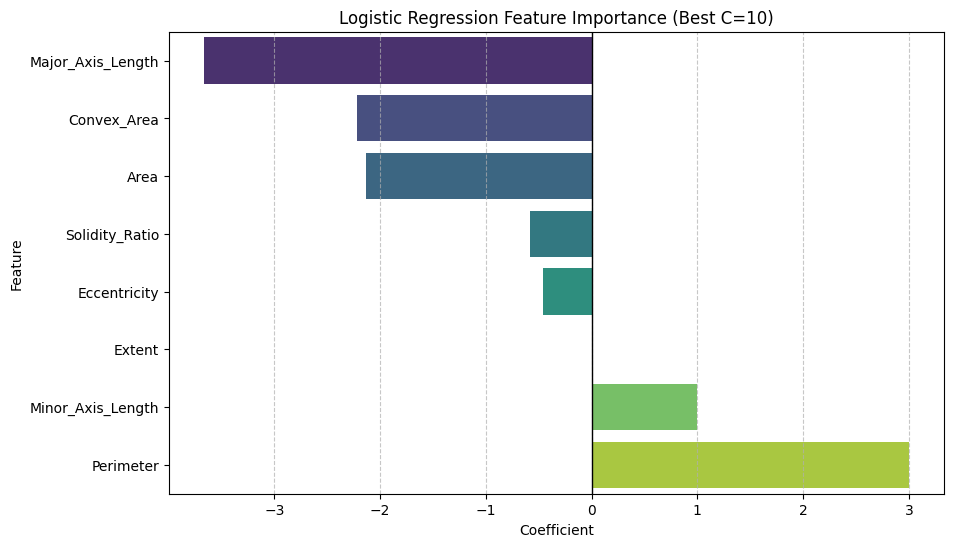

Numerical Feature Importance:
          Feature  Coefficient
Major_Axis_Length    -3.663858
        Perimeter     2.997130
      Convex_Area    -2.216716
             Area    -2.130123
Minor_Axis_Length     1.001501
   Solidity_Ratio    -0.584675
     Eccentricity    -0.463100
           Extent     0.002255

Interpretation Note: Positive coefficients increase the probability of Class 1 (Osmancik),
while negative coefficients increase the probability of Class 0 (Cammeo).


In [27]:
# 1. Extract coefficients from the FINAL optimized model
importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': final_log_reg.coef_[0]})

# 2. Sort by absolute value to show the most "influential" features first
importance['Abs_Coefficient'] = importance['Coefficient'].abs()
importance = importance.sort_values(by='Abs_Coefficient', ascending=False)

# 3. Visualize
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=importance.sort_values(by='Coefficient'), palette="viridis")
plt.title(f'Logistic Regression Feature Importance (Best C={best_c})')
plt.axvline(x=0, color='black', linestyle='-', linewidth=1) # Adds a center line at 0
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 4. Print values for report summary
print("Numerical Feature Importance:")
print(importance[['Feature', 'Coefficient']].to_string(index=False))

print("\nInterpretation Note: Positive coefficients increase the probability of Class 1 (Osmancik),")
print("while negative coefficients increase the probability of Class 0 (Cammeo).")